In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
img = cv2.imread('cat.png', 0)

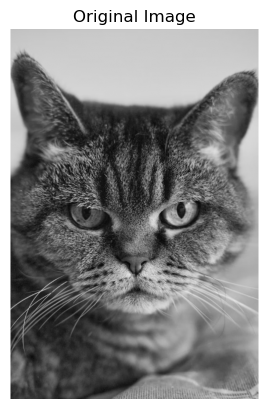

In [9]:
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [12]:
# convert frequency domain manually
def fft1d(x):
    N = len(x)
    if N <= 1:
        return x
    even = fft1d(x[0::2])
    odd = fft1d(x[1::2])
    T = [np.exp(-2j * np.pi * k / N) * odd[k] for k in range(N // 2)]
    return [even[k] + T[k] for k in range(N // 2)] + [even[k] - T[k] for k in range(N // 2)]


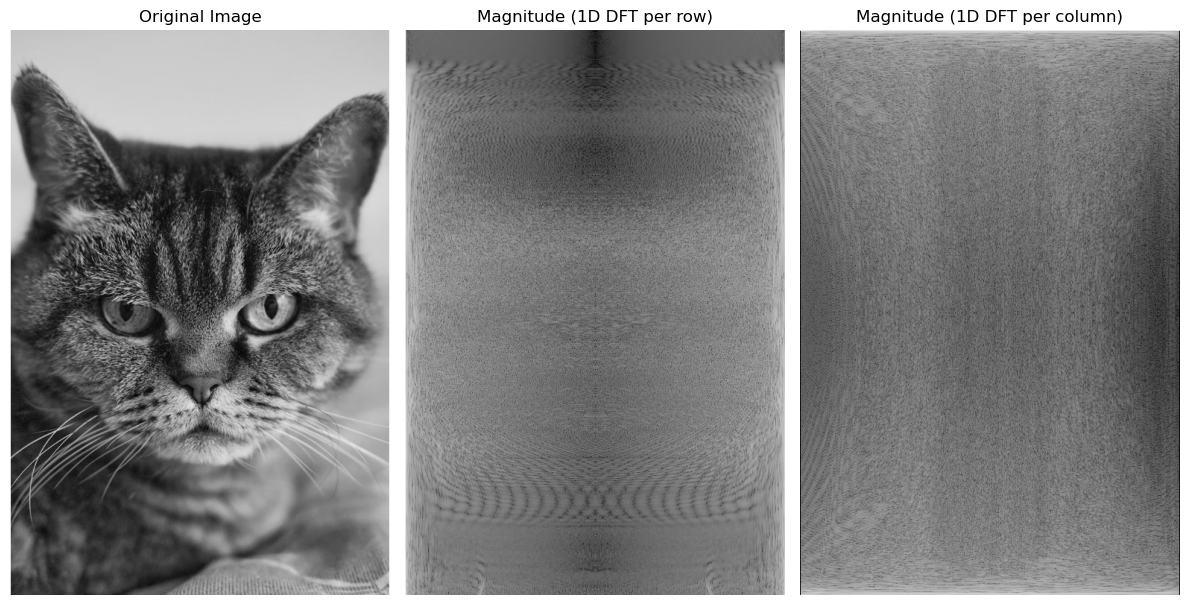

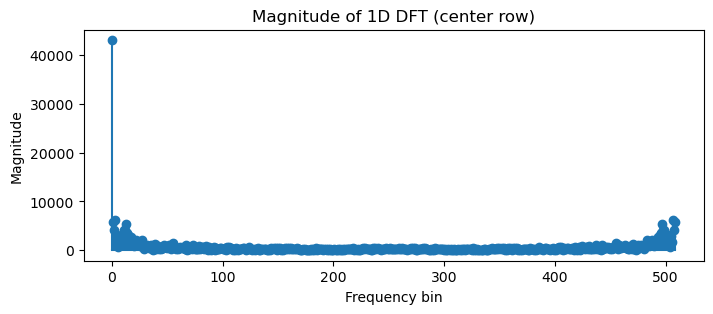

In [15]:
# Compute 1D DFT along rows and columns using direct DFT matrix
img_f = img.astype(np.float64)
H, W = img_f.shape
# DFT along rows (length W)
n = np.arange(W)
k = n.reshape((W,1))
W_row = np.exp(-2j * np.pi * k * n / W)
dft_rows = img_f.dot(W_row.T)
mag_rows = np.log(1 + np.abs(dft_rows))
# DFT along columns (length H)
m = np.arange(H)
l = m.reshape((H,1))
W_col = np.exp(-2j * np.pi * l * m / H)
dft_cols = W_col.dot(img_f)
mag_cols = np.log(1 + np.abs(dft_cols))
# Plotting
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title('Magnitude (1D DFT per row)')
plt.imshow(mag_rows, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title('Magnitude (1D DFT per column)')
plt.imshow(mag_cols, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()
# Show 1D DFT for center row
center_row = img_f[H//2,:]
W_s = np.exp(-2j * np.pi * np.outer(np.arange(W), np.arange(W)) / W)
dft_center = W_s.dot(center_row)
plt.figure(figsize=(8,3))
plt.stem(np.arange(W), np.abs(dft_center), linefmt='C0-', markerfmt='C0o', basefmt='C0-')
plt.title('Magnitude of 1D DFT (center row)')
plt.xlabel('Frequency bin')
plt.ylabel('Magnitude')
plt.show()